In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chi2, t
from scipy.stats import chisquare, geom
import scipy.stats as stats
np.random.seed(42)

In [2]:
def histogram(x, bins=10, text="Histogram of randomly generated number from Geometric distribution"):
    plt.hist(x, bins=bins)
    plt.title(text)
    plt.show()

## Exercise 1

In [22]:
def sample_exponential_distribution(U, lamd=1):
    return -np.log(U) / lamd


def sample_normal_distribution(U):
    U_reshaped = U.reshape(-1,2)
    length = np.sqrt(-2*np.log(U_reshaped[:, 0]))
    Z1 = length * np.cos(2*np.pi*U_reshaped[:,1])
    Z2 = length * np.sin(2*np.pi*U_reshaped[:,1])
    
    return np.concatenate((Z1, Z2))
    
    
def sample_pareto_distribution(n, beta=1, k=2.001):
    U = np.random.rand(n)
    return beta * U**(-1/k) # = Y

def pareto_exp_var(X, k, beta):
    # Analytical
    analytical_mean = beta * k / (k - 1)
    analytical_var = (beta**2 * k) / ((k-1)**2 * (k-2))
    
    # Empirical
    empirical_mean = np.mean(X)
    empirical_var = np.var(X, ddof=1)
    
    print(f"Analytical mean: {analytical_mean:.4f}")
    print(f"Empirical mean:  {empirical_mean:.4f}")
    print(f"Analytical variance: {analytical_var:.4f}")
    print(f"Empirical variance:  {empirical_var:.4f}")


def CI_mean(means, confidence=0.95):
    n = len(means)
    mean = np.mean(means)
    t_test_statistic = t.ppf(1 - 0.05/2, df=n-1)
    S_n = np.std(means, ddof=1)
    lower_bound = mean - t_test_statistic * S_n / np.sqrt(n)
    upper_bound = mean + t_test_statistic * S_n / np.sqrt(n)
    return mean,lower_bound, upper_bound


def CI_std(x, confidence=0.95):
    n = len(x)
    S = np.std(x, ddof=1)
    alpha = 1 - confidence
    
    lower = np.sqrt((n-1) * S**2 / chi2.ppf(1 - alpha/2, df=n-1))
    upper = np.sqrt((n-1) * S**2 / chi2.ppf(alpha/2, df=n-1))
    
    return S, lower, upper



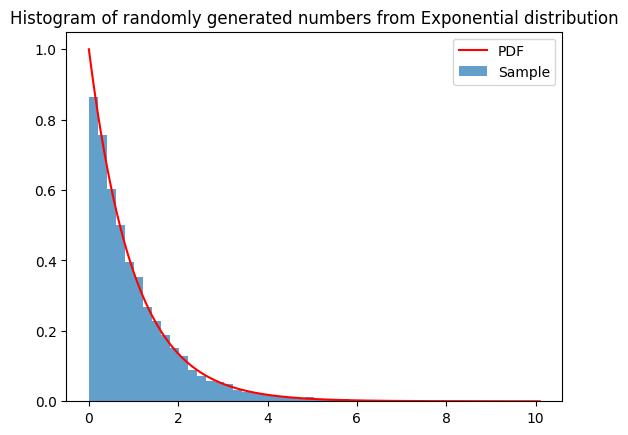

In [11]:
U = np.random.rand(10000)

X_exp_sample = sample_exponential_distribution(U, lamd=1)
x_range = np.linspace(min(X_exp_sample), max(X_exp_sample), 1000)

plt.plot(x_range, stats.expon.pdf(x_range), color='red', label='PDF')
plt.hist(X_exp_sample, bins=50, density=True, alpha=0.7, label='Sample')
plt.title("Histogram of randomly generated numbers from Exponential distribution")
plt.legend()
plt.show()

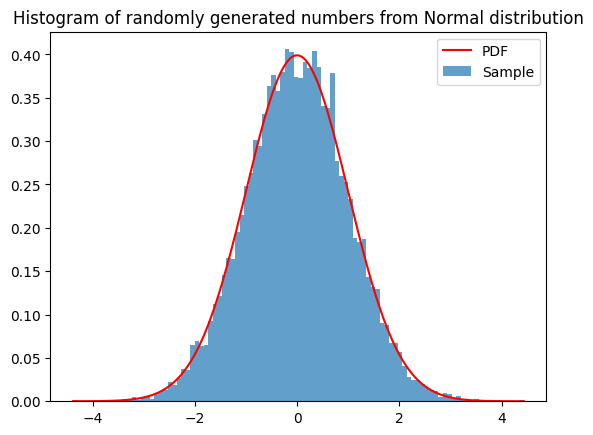

CI of Mean: (np.float64(0.003453113932594779), np.float64(-0.016106020947230803), np.float64(0.023012248812420363))
CI of standard deviation: (np.float64(0.997812583983913), np.float64(0.9974035293199475), np.float64(0.9982884956995782))


In [14]:
U = np.random.rand(10000)



X_normal_sample = sample_normal_distribution(U)
x_range = np.linspace(min(X_normal_sample), max(X_normal_sample), 1000)

plt.plot(x_range, stats.norm.pdf(x_range, 0, 1), color='red', label='PDF')
plt.hist(X_normal_sample, bins=100, density=True, alpha=0.7, label='Sample')
plt.title("Histogram of randomly generated numbers from Normal distribution")
plt.legend()
plt.show()

print("CI of Mean:",CI_mean(X_normal_sample, confidence=0.05))
print("CI of standard deviation:",CI_std(X_normal_sample, confidence=0.05))


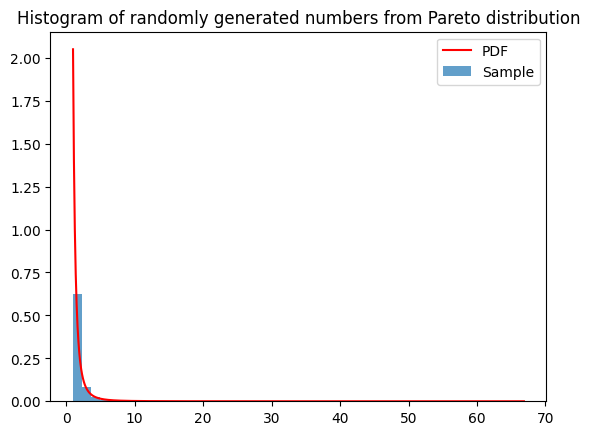

Analytical mean: 1.9524
Empirical mean:  1.9172
Analytical variance: 37.1882
Empirical variance:  4.0971


In [24]:
beta, k = 1, 2.05
n = 10000

X_pareto_sample = sample_pareto_distribution(n, beta=beta, k=k)
x_range = np.linspace(min(X_pareto_sample), max(X_pareto_sample), 1000)

plt.plot(x_range, stats.pareto.pdf(x_range, b=k, scale=beta), color='red', label='PDF')
plt.hist(X_pareto_sample, bins=50, density=True, alpha=0.7, label='Sample')
plt.title("Histogram of randomly generated numbers from Pareto distribution")
plt.legend()
plt.show()

pareto_exp_var(X_pareto_sample, k, beta);

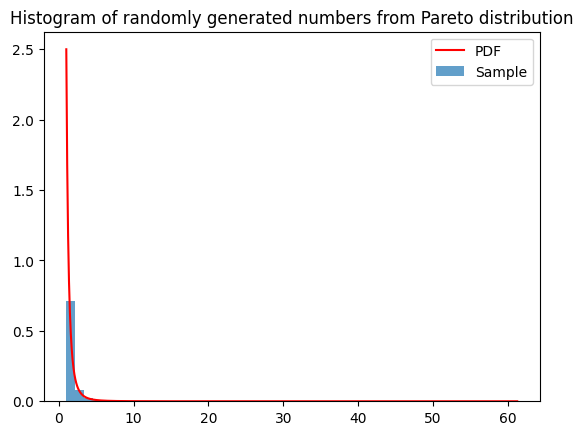

Analytical mean: 1.6667
Empirical mean:  1.6923
Analytical variance: 2.2222
Empirical variance:  1.9599


In [25]:
beta, k = 1, 2.5

X_pareto_sample = sample_pareto_distribution(n, beta=beta, k=k)
x_range = np.linspace(min(X_pareto_sample), max(X_pareto_sample), 1000)

plt.plot(x_range, stats.pareto.pdf(x_range, b=k, scale=beta), color='red', label='PDF')
plt.hist(X_pareto_sample, bins=50, density=True, alpha=0.7, label='Sample')
plt.title("Histogram of randomly generated numbers from Pareto distribution")
plt.legend()
plt.show()

pareto_exp_var(X_pareto_sample, k, beta);

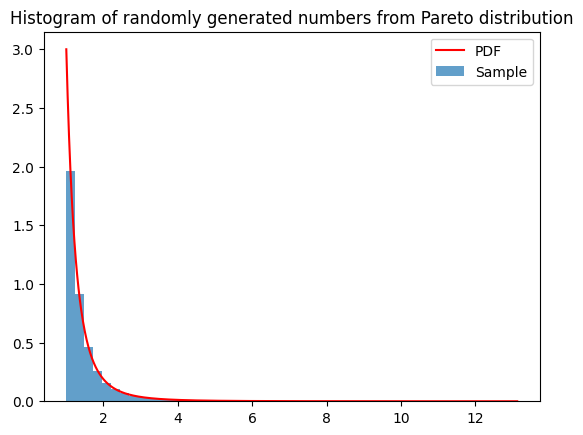

Analytical mean: 1.5000
Empirical mean:  1.4885
Analytical variance: 0.7500
Empirical variance:  0.5273


In [26]:
beta, k = 1, 3


X_pareto_sample = sample_pareto_distribution(n, beta=beta, k=k)
x_range = np.linspace(min(X_pareto_sample), max(X_pareto_sample), 1000)

plt.plot(x_range, stats.pareto.pdf(x_range, b=k, scale=beta), color='red', label='PDF')
plt.hist(X_pareto_sample, bins=50, density=True, alpha=0.7, label='Sample')
plt.title("Histogram of randomly generated numbers from Pareto distribution")
plt.legend()
plt.show()

pareto_exp_var(X_pareto_sample, k, beta);

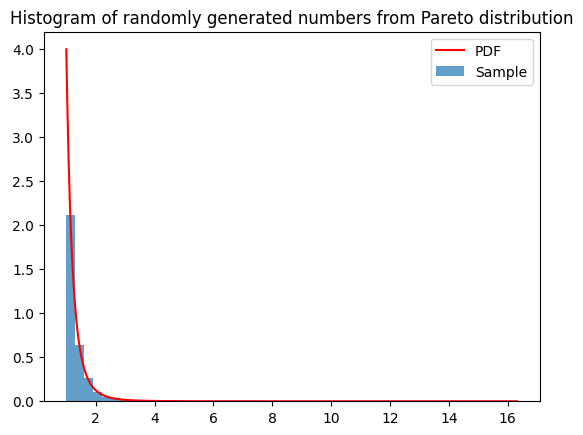

Analytical mean: 1.3333
Empirical mean:  1.3389
Analytical variance: 0.2222
Empirical variance:  0.2179


In [27]:
beta, k = 1, 4


X_pareto_sample = sample_pareto_distribution(n, beta=beta, k=k)
x_range = np.linspace(min(X_pareto_sample), max(X_pareto_sample), 1000)

plt.plot(x_range, stats.pareto.pdf(x_range, b=k, scale=beta), color='red', label='PDF')
plt.hist(X_pareto_sample, bins=50, density=True, alpha=0.7, label='Sample')
plt.title("Histogram of randomly generated numbers from Pareto distribution")
plt.legend()
plt.show()

pareto_exp_var(X_pareto_sample, k, beta);

## Exercise 3

In [28]:
trials = 100
nr_samples = 10

ci_mean = np.zeros((trials, 3))      # mean, lower, upper
ci_variance = np.zeros((trials, 3))  # std, lower, upper

for i in range(trials):
    U = np.random.rand(nr_samples)
    X_normal_sample = sample_normal_distribution(U)
    
    ci_mean[i] = CI_mean(X_normal_sample)
    ci_variance[i] = CI_std(X_normal_sample)
    
print(np.mean(ci_mean, axis=0), np.mean(ci_variance, axis=0))
print(np.var(ci_mean, axis=0), np.var(ci_variance, axis=0))

[ 0.00124105 -0.68577196  0.68825407] [0.96037797 0.66058178 1.75327581]
[0.10925354 0.1348621  0.12064295] [0.0361495  0.01710295 0.12048096]


In [3]:
def confidence_intervals(num_intervals=100, n=10, confidence=0.95):
    alpha = 1 - confidence
    # Critical values
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)
    chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)
    
    mean_hits = 0
    var_hits = 0
    
    # Normal distribution parameters
    mu_true, var_true = 0, 1
    
    for _ in range(num_intervals):
        data = np.random.normal(mu_true, np.sqrt(var_true), n)
        s_mean = np.mean(data)
        s_var = np.var(data, ddof=1)
        
        # Confidence Interval for the Mean
        ci_mean = (s_mean - t_crit * np.sqrt(s_var/n), s_mean + t_crit * np.sqrt(s_var/n))
        if ci_mean[0] <= mu_true <= ci_mean[1]:
            mean_hits += 1
            
        # Confidence Interval for the Variance
        ci_var = ((n-1)*s_var / chi2_upper, (n-1)*s_var / chi2_lower)
        if ci_var[0] <= var_true <= ci_var[1]:
            var_hits += 1
            
    print(f"Mean Coverage: {mean_hits/num_intervals*100}%")
    print(f"Variance Coverage: {var_hits/num_intervals*100}%")

confidence_intervals()

Mean Coverage: 95.0%
Variance Coverage: 97.0%


## Exercise 4

In [29]:
n = 1000
n_simulations = 100
beta = 1
k_values = [2.05, 2.5, 3, 4]
means = np.zeros((n_simulations, len(k_values)))
variances = np.zeros((n_simulations, len(k_values)))


for k in k_values:
    for i in range(n_simulations):
        X = sample_pareto_distribution(n, beta=beta, k=k)
        means[i, k_values.index(k)] = np.mean(X)
        variances[i, k_values.index(k)] = np.var(X)
    mean, lower_bound, upper_bound = CI_mean(means[:, k_values.index(k)], confidence=0.95)
    print(f"Results for k={k}:")
    print(f"Analytical mean: {(k)*beta/(k-1):.4f}")
    print(f"Mean: {mean:.4f}")
    print(f"Confidence interval for mean (k={k}): [{lower_bound:.4f}, {upper_bound:.4f}]")
    mean, lower_bound, upper_bound = CI_std(variances[:, k_values.index(k)], confidence=0.95)
    print(f"Analytical variance: {k*beta**2/((k-1)**2 * (k-2)):.4f}")
    print(f"Variance: {mean:.4f}")
    print(f"Confidence interval for std (k={k}): [{lower_bound:.4f}, {upper_bound:.4f}]")
    print("-"*40)
    


Results for k=2.05:
Analytical mean: 1.9524
Mean: 1.9496
Confidence interval for mean (k=2.05): [1.9321, 1.9671]
Analytical variance: 37.1882
Variance: 10.7431
Confidence interval for std (k=2.05): [9.4325, 12.4800]
----------------------------------------
Results for k=2.5:
Analytical mean: 1.6667
Mean: 1.6713
Confidence interval for mean (k=2.5): [1.6621, 1.6805]
Analytical variance: 2.2222
Variance: 5.5021
Confidence interval for std (k=2.5): [4.8309, 6.3917]
----------------------------------------
Results for k=3:
Analytical mean: 1.5000
Mean: 1.5064
Confidence interval for mean (k=3): [1.5001, 1.5126]
Analytical variance: 0.7500
Variance: 0.6350
Confidence interval for std (k=3): [0.5576, 0.7377]
----------------------------------------
Results for k=4:
Analytical mean: 1.3333
Mean: 1.3331
Confidence interval for mean (k=4): [1.3304, 1.3359]
Analytical variance: 0.2222
Variance: 0.0656
Confidence interval for std (k=4): [0.0576, 0.0762]
----------------------------------------
